| 项目 | 内容 |
|------|------|
| **标题** | KNN算法与Numpy实现 |
| **作者** | 邓涵丹 |
| **周次** | Week 2 |
| **分类** |机器学习 / 监督学习 / 分类算法|
| **学习目标** |1. 理解KNN算法的三要素（距离度量、K值选择、分类决策规则）。2. 掌握基于Numpy的向量化距离计算与KNN从零实现（含封装类）。3. 分析K值对模型性能的影响，并通过可视化选择最优K值。4. 认识数据标准化（归一化）对KNN距离计算的重要性及效果对比。|
# K-NN算法

# KNN 算法原理与 Numpy 实现

## 1. 算法简介

**K 近邻算法 (K-Nearest Neighbors, KNN)** 是一种基本且经典的分类与回归方法。  
它的核心思想非常简单：**“近朱者赤，近墨者黑”**。  
对于一个待分类的样本，在特征空间中寻找与之最相似的 K 个训练样本，然后根据这 K 个邻居的类别，通过多数投票等方式决定新样本的类别。

KNN 是一种 **惰性学习** 算法，没有显式的训练过程，所有计算都推迟到预测阶段进行。

## 2. 算法三要素

KNN 模型由三个基本要素决定：
1. **距离度量**：如何衡量样本之间的相似程度（欧氏距离、曼哈顿距离、闵可夫斯基距离等）。
2. **K 值的选择**：选择多少个邻居参与投票。
3. **分类决策规则**：多数投票规则（或加权投票）。
## 3. 距离度量

设特征空间中两个样本点 $x_i = (x_i^{(1)}, x_i^{(2)}, \dots, x_i^{(n)})$ 和 $x_j = (x_j^{(1)}, x_j^{(2)}, \dots, x_j^{(n)})$。

- **欧氏距离 (Euclidean Distance)**  
  $$d(x_i, x_j) = \sqrt{\sum_{l=1}^{n} (x_i^{(l)} - x_j^{(l)})^2}$$
- **曼哈顿距离 (Manhattan Distance)**  
  $$d(x_i, x_j) = \sum_{l=1}^{n} |x_i^{(l)} - x_j^{(l)}|$$
- **闵可夫斯基距离 (Minkowski Distance)**  
  $$d(x_i, x_j) = \left( \sum_{l=1}^{n} |x_i^{(l)} - x_j^{(l)}|^p \right)^{1/p}$$

$p=2$ 时为欧氏距离，$p=1$ 时为曼哈顿距离。

在后面的代码实现中，我们将重点使用 **欧氏距离**，并给出一个向量化的高效计算方式。

## 4. 数据预处理的重要性

KNN 基于距离计算，特征的量纲对结果影响巨大。  
例如：身高（cm）和体重（kg）尺度不同，若不做归一化，计算距离时体重的微弱差异可能掩盖身高的巨大差异。  
因此通常在使用 KNN 前需要对特征进行 **标准化（Z-score）** 或 **归一化（Min-Max）** 处理。
## 5. Numpy 实现 KNN 分类器

我们将从零开始，仅使用 `numpy` 构建一个 KNN 分类器。

In [1]:
import numpy as np
from collections import Counter


### 5.1 距离计算函数

使用向量化方式计算单个测试样本与所有训练样本之间的欧氏距离。

In [2]:

def euclidean_distance(x_test, X_train):
    """
    计算一个测试样本与所有训练样本之间的欧氏距离。
    
    参数：
    x_test:  shape (n_features,)
    X_train: shape (n_samples, n_features)
    
    返回：
    distances: shape (n_samples,) 每个训练样本到 x_test 的距离
    """
    # 利用广播机制：(x_test - X_train) 维度为 (n_samples, n_features)
    # 平方后按 axis=1 求和，再开方
    return np.sqrt(np.sum((x_test - X_train) ** 2, axis=1))


### 5.2 预测单个样本

In [3]:

def predict_single(x_test, X_train, y_train, k):
    """
    对单个测试样本进行 KNN 预测。
    """
    distances = euclidean_distance(x_test, X_train)
    # 获取距离最近的 k 个样本的索引
    k_nearest_indices = np.argsort(distances)[:k]
    # 取出这些邻居的标签
    k_nearest_labels = y_train[k_nearest_indices]
    # 多数投票
    most_common = Counter(k_nearest_labels).most_common(1)
    return most_common[0][0]


### 5.3 批量预测

In [4]:

def predict(X_test, X_train, y_train, k):
    """
    对多个测试样本进行预测。
    
    参数：
    X_test: shape (m, n_features)
    X_train: shape (n, n_features)
    y_train: shape (n,)
    k: 邻居个数
    
    返回：
    y_pred: shape (m,) 预测标签
    """
    y_pred = [predict_single(x, X_train, y_train, k) for x in X_test]
    return np.array(y_pred)


### 5.4 封装成类

In [5]:

class KNNClassifier:
    def __init__(self, k=3):
        self.k = k
        
    def fit(self, X_train, y_train):
        """KNN 只是存储训练数据，没有实际训练过程。"""
        self.X_train = X_train
        self.y_train = y_train
        
    def predict(self, X_test):
        """预测测试集标签。"""
        return predict(X_test, self.X_train, self.y_train, self.k)


## 6. 在 Iris 数据集上测试

我们将使用经典的鸢尾花数据集，并手动划分训练集和测试集。

In [6]:

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 加载数据
iris = load_iris()
X, y = iris.data, iris.target

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 特征标准化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 创建 KNN 分类器（k=3）
knn = KNNClassifier(k=3)
knn.fit(X_train, y_train)

# 预测
y_pred = knn.predict(X_test)

# 评估准确率
acc = accuracy_score(y_test, y_pred)
print(f"KNN (k=3) 在 Iris 测试集上的准确率: {acc:.4f}")

KNN (k=3) 在 Iris 测试集上的准确率: 1.0000



## 7. K 值的影响

K 值的选择对模型性能至关重要：
- **K 太小**：模型复杂，容易过拟合，对噪声敏感。
- **K 太大**：模型简单，容易欠拟合，边界模糊。

下面我们观察不同 K 值下的准确率变化。

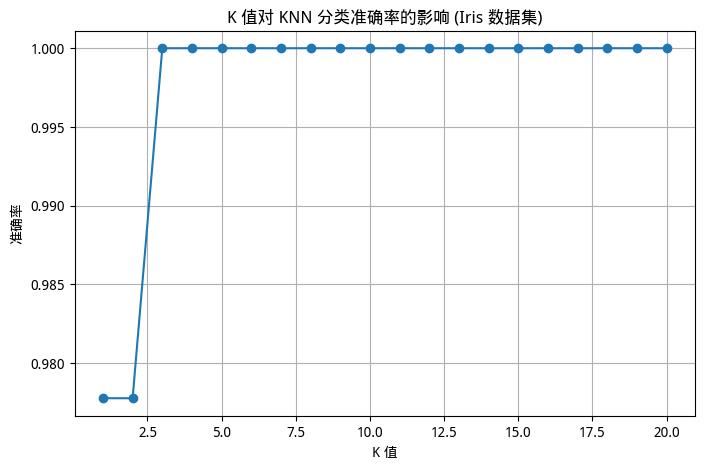

In [7]:

import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["WenQuanYi Micro Hei"]
plt.rcParams["axes.unicode_minus"] = False
k_range = range(1, 21)
accuracies = []

for k in k_range:
    knn = KNNClassifier(k=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(k_range, accuracies, marker='o')
plt.xlabel('K 值')
plt.ylabel('准确率')
plt.title('K 值对 KNN 分类准确率的影响 (Iris 数据集)')
plt.grid(True)
plt.show()


一般通过交叉验证来选择最优的 K 值。

## 8. 归一化效果对比

为了直观展示归一化的重要性，我们将对比原始数据与标准化后数据的距离计算效果。

In [8]:

# 原始数据（前两个特征）
X_raw = iris.data[:, :2]
y_raw = iris.target

# 标准化数据
scaler2 = StandardScaler()
X_std = scaler2.fit_transform(X_raw)

# 划分原始数据的训练/测试集
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_raw, y_raw, test_size=0.3, random_state=42)
# 划分标准化数据的训练/测试集
Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_std, y_raw, test_size=0.3, random_state=42)

knn_raw = KNNClassifier(k=3)
knn_raw.fit(Xr_train, yr_train)
acc_raw = accuracy_score(yr_test, knn_raw.predict(Xr_test))

knn_std = KNNClassifier(k=3)
knn_std.fit(Xs_train, ys_train)
acc_std = accuracy_score(ys_test, knn_std.predict(Xs_test))

print(f"未归一化准确率: {acc_raw:.4f}")
print(f"标准化后准确率: {acc_std:.4f}")

未归一化准确率: 0.7556
标准化后准确率: 0.8000



可视化决策边界可以更清晰地看到差异，这里代码省略，可直接从参考资料中获取。

## 9. 优缺点总结

### 优点
- 原理简单，易于理解和实现。
- 无需训练过程，适用于增量学习。
- 对异常值不敏感（多数投票可以减弱个别异常值的影响）。
- 可用于多分类和回归。

### 缺点
- 计算复杂度高，预测时需要计算与所有训练样本的距离，数据量大时速度慢。
- 需要大量内存存储全部训练数据。
- 对高维数据效果不佳（维度灾难）。
- 受数据不平衡影响较大。

## 10. 参考资料

本报告的撰写主要参考了以下三篇优质文章，它们对 KNN 的原理与代码实现进行了详细的讲解：

1. CSDN - pengjunlee：《KNN算法及其python实现》  
   https://blog.csdn.net/pengjunlee/article/details/82713047

2. 知乎专栏：《机器学习算法——K近邻(KNN)算法原理及Python实现》  
   https://zhuanlan.zhihu.com/p/64373771

3. CSDN - gitblog_00794：《KNN算法详解及Python实现》  
   https://blog.csdn.net/gitblog_00794/article/details/149853586


以上就是基于 Numpy 的 KNN 算法完整分享报告。你可以将以上单元格依次放入 Jupyter Notebook 中执行，体验从零构建 KNN 的过程。